In [24]:
try:
    import torch
    print("PyTorch is installed.")
    print("Version:", torch.__version__)
except ImportError:
    print("PyTorch is NOT installed.")

PyTorch is NOT installed.


In [25]:
import numpy
import pandas
import sklearn
import matplotlib

print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 2.4.6
Pandas: 3.0.2
Scikit-learn: 1.8.0
Matplotlib: 3.10.8


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [27]:
np.random.seed(42)

# Number of trading days
n_days = 1000

# Generate dates
dates = pd.date_range(
    start="2020-01-01",
    periods=n_days,
    freq="D"
)

# Generate realistic-looking stock movement
daily_returns = np.random.normal(
    loc=0.0005,
    scale=0.02,
    size=n_days
)

# Generate prices
prices = 100 * np.exp(
    np.cumsum(daily_returns)
)

# Create DataFrame
df = pd.DataFrame({
    "Date": dates,
    "Close": prices
})

print("Dataset created successfully!")
print("Number of records:", len(df))

display(df.head())

Dataset created successfully!
Number of records: 1000


,Date,Close
0,2020-01-01,101.048891
1,2020-01-02,100.820245
2,2020-01-03,102.185823
3,2020-01-04,105.399042
4,2020-01-05,104.959072


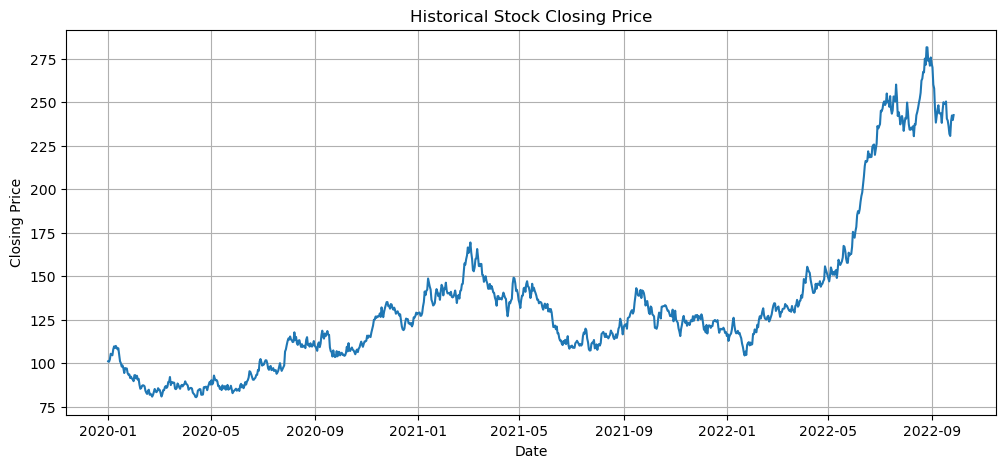

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title("Historical Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

In [29]:
data = df["Close"].values.reshape(-1, 1)

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Original price:", data[0][0])
print("Normalized price:", scaled_data[0][0])

Original price: 101.04889100241274
Normalized price: 0.10252508741068855


In [30]:
sequence_length = 30

X = []
y = []

for i in range(
    sequence_length,
    len(scaled_data)
):
    
    X.append(
        scaled_data[
            i-sequence_length:i,
            0
        ]
    )
    
    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (970, 30)
Output shape: (970,)


In [31]:
train_size = int(
    len(X) * 0.80
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 776
Testing samples: 194


In [32]:
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Model training completed!


In [33]:
predictions = model.predict(X_test)

predicted_prices = scaler.inverse_transform(
    predictions.reshape(-1, 1)
)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Prediction completed!")

Prediction completed!


In [9]:
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 0
Testing samples: 0


In [34]:
rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("=" * 40)
print("MODEL PERFORMANCE")
print("=" * 40)

print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))

MODEL PERFORMANCE
RMSE: 18.3
MAE : 14.52


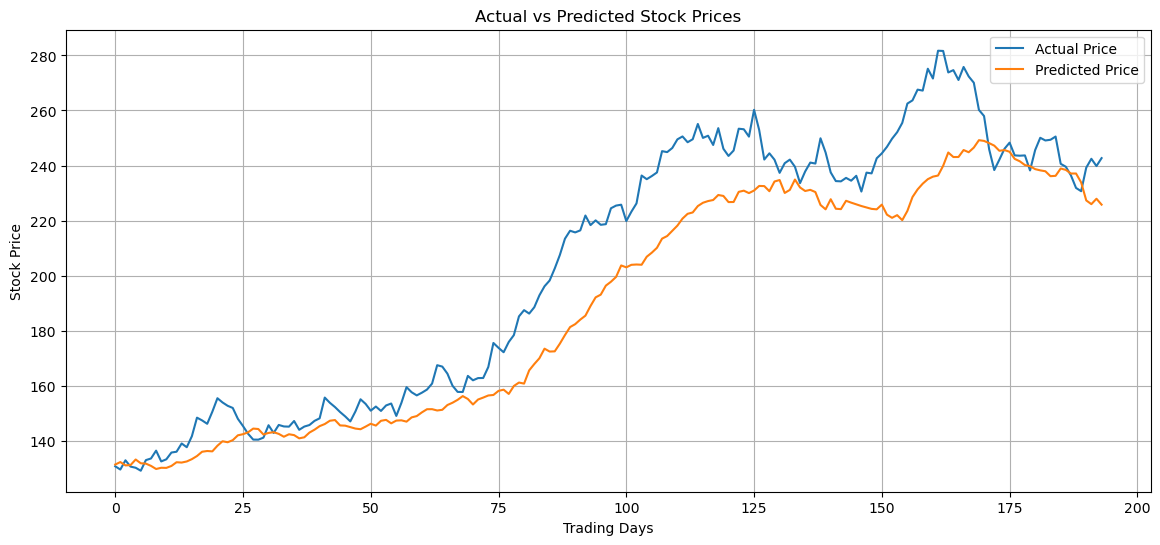

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predicted_prices,
    label="Predicted Price"
)

plt.title(
    "Actual vs Predicted Stock Prices"
)

plt.xlabel("Trading Days")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.show()

In [36]:
backtest = pd.DataFrame({
    "Actual_Price": actual_prices.flatten(),
    "Predicted_Price": predicted_prices.flatten()
})

# Trading signal
backtest["Signal"] = np.where(
    backtest["Predicted_Price"] >
    backtest["Actual_Price"],
    1,
    -1
)

# Market return
backtest["Market_Return"] = (
    backtest["Actual_Price"].pct_change()
)

# Strategy return
backtest["Strategy_Return"] = (
    backtest["Signal"].shift(1)
    * backtest["Market_Return"]
)

backtest = backtest.dropna()

# Cumulative returns
backtest["Market_Cumulative"] = (
    1 + backtest["Market_Return"]
).cumprod()

backtest["Strategy_Cumulative"] = (
    1 + backtest["Strategy_Return"]
).cumprod()

display(backtest.head(10))

,Actual_Price,Predicted_Price,Signal,Market_Return,Strategy_Return,Market_Cumulative,Strategy_Cumulative
1,129.531170,132.247813,1,-0.009034,-0.009034,0.990966,0.990966
2,132.891987,131.043979,-1,0.025946,0.025946,1.016678,1.016678
3,130.600693,131.150471,1,-0.017242,0.017242,0.999148,1.034207
4,130.178566,133.178884,1,-0.003232,-0.003232,0.995919,1.030864
5,129.103250,131.806045,1,-0.008260,-0.008260,0.987692,1.022349
6,132.960491,131.682403,-1,0.029877,0.029877,1.017202,1.052894
7,133.550959,130.861719,-1,0.004441,-0.004441,1.021719,1.048218
8,136.403856,129.731389,-1,0.021362,-0.021362,1.043545,1.025826
9,132.476968,130.175883,-1,-0.028789,0.028789,1.013503,1.055358
10,133.253031,130.131552,-1,0.005858,-0.005858,1.019440,1.049176


In [37]:
backtest = pd.DataFrame({
    "Actual_Price": actual_prices.flatten(),
    "Predicted_Price": predicted_prices.flatten()
})

# Trading signal
backtest["Signal"] = np.where(
    backtest["Predicted_Price"] >
    backtest["Actual_Price"],
    1,
    -1
)

# Market return
backtest["Market_Return"] = (
    backtest["Actual_Price"].pct_change()
)

# Strategy return
backtest["Strategy_Return"] = (
    backtest["Signal"].shift(1)
    * backtest["Market_Return"]
)

backtest = backtest.dropna()

# Cumulative returns
backtest["Market_Cumulative"] = (
    1 + backtest["Market_Return"]
).cumprod()

backtest["Strategy_Cumulative"] = (
    1 + backtest["Strategy_Return"]
).cumprod()

display(backtest.head(10))

,Actual_Price,Predicted_Price,Signal,Market_Return,Strategy_Return,Market_Cumulative,Strategy_Cumulative
1,129.531170,132.247813,1,-0.009034,-0.009034,0.990966,0.990966
2,132.891987,131.043979,-1,0.025946,0.025946,1.016678,1.016678
3,130.600693,131.150471,1,-0.017242,0.017242,0.999148,1.034207
4,130.178566,133.178884,1,-0.003232,-0.003232,0.995919,1.030864
5,129.103250,131.806045,1,-0.008260,-0.008260,0.987692,1.022349
6,132.960491,131.682403,-1,0.029877,0.029877,1.017202,1.052894
7,133.550959,130.861719,-1,0.004441,-0.004441,1.021719,1.048218
8,136.403856,129.731389,-1,0.021362,-0.021362,1.043545,1.025826
9,132.476968,130.175883,-1,-0.028789,0.028789,1.013503,1.055358
10,133.253031,130.131552,-1,0.005858,-0.005858,1.019440,1.049176


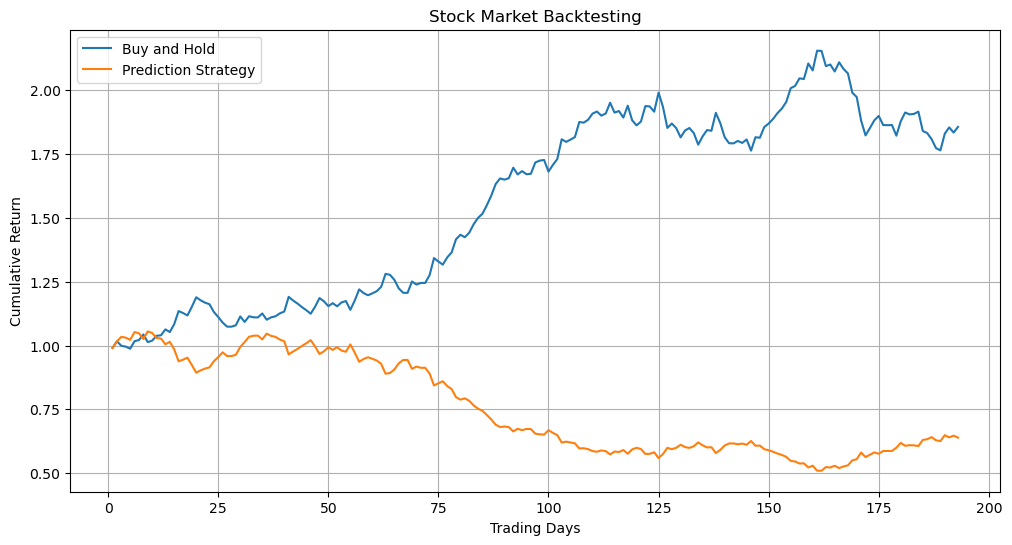

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    backtest["Market_Cumulative"],
    label="Buy and Hold"
)

plt.plot(
    backtest["Strategy_Cumulative"],
    label="Prediction Strategy"
)

plt.title("Stock Market Backtesting")

plt.xlabel("Trading Days")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)

plt.show()

In [39]:
latest_sequence = scaled_data[-sequence_length:]

latest_sequence = latest_sequence.reshape(
    1,
    sequence_length
)

next_scaled_price = model.predict(
    latest_sequence
)

next_price = scaler.inverse_transform(
    next_scaled_price.reshape(-1, 1)
)

print(
    "Predicted Next Day Closing Price:",
    round(float(next_price[0][0]), 2)
)

Predicted Next Day Closing Price: 225.03


In [40]:
future_prices = []

sequence = scaled_data[-sequence_length:].flatten()

for day in range(5):

    input_data = sequence.reshape(
        1,
        sequence_length
    )

    prediction = model.predict(
        input_data
    )[0]

    future_prices.append(prediction)

    sequence = np.append(
        sequence[1:],
        prediction
    )

future_prices = scaler.inverse_transform(
    np.array(future_prices).reshape(-1, 1)
)

print("5-Day Stock Price Forecast")
print("-" * 30)

for i, price in enumerate(
    future_prices,
    start=1
):
    print(
        f"Day {i}: {price[0]:.2f}"
    )

5-Day Stock Price Forecast
------------------------------
Day 1: 225.03
Day 2: 222.91
Day 3: 217.07
Day 4: 215.06
Day 5: 214.40


In [41]:
future_prices = []

sequence = scaled_data[-sequence_length:].flatten()

for day in range(5):

    input_data = sequence.reshape(
        1,
        sequence_length
    )

    prediction = model.predict(
        input_data
    )[0]

    future_prices.append(prediction)

    sequence = np.append(
        sequence[1:],
        prediction
    )

future_prices = scaler.inverse_transform(
    np.array(future_prices).reshape(-1, 1)
)

print("5-Day Stock Price Forecast")
print("-" * 30)

for i, price in enumerate(
    future_prices,
    start=1
):
    print(
        f"Day {i}: {price[0]:.2f}"
    )

5-Day Stock Price Forecast
------------------------------
Day 1: 225.03
Day 2: 222.91
Day 3: 217.07
Day 4: 215.06
Day 5: 214.40


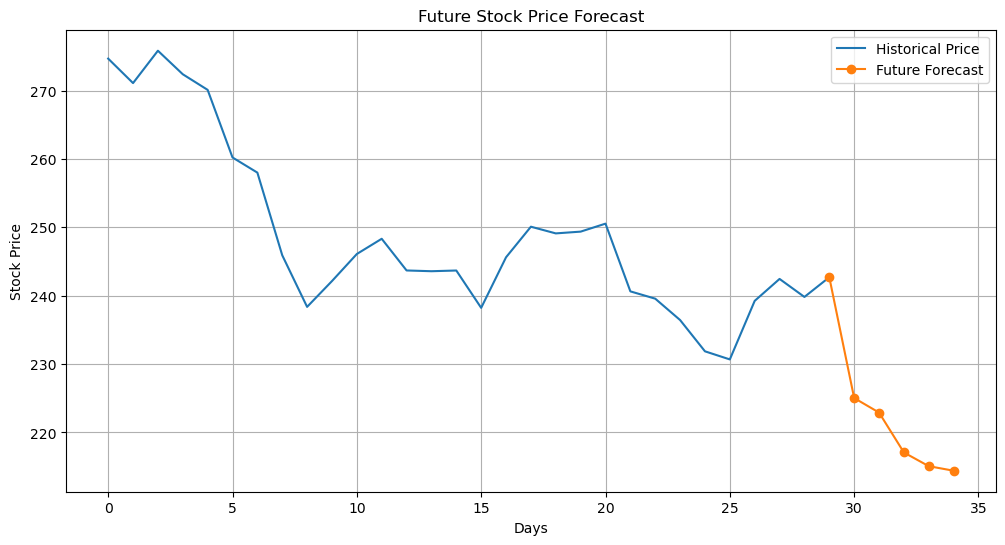

In [44]:
# ==========================================
# FUTURE STOCK PRICE FORECAST PLOT
# ==========================================

plt.figure(figsize=(12, 6))

# Last 30 historical prices
plt.plot(
    range(30),
    historical_prices,
    label="Historical Price"
)

# Forecast starts from the last historical day
forecast_values = np.concatenate([
    [historical_prices[-1]],
    future_prices.flatten()
])

# 6 X values for 6 Y values
forecast_x = range(29, 35)

plt.plot(
    forecast_x,
    forecast_values,
    marker="o",
    label="Future Forecast"
)

plt.title("Future Stock Price Forecast")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
print("=" * 50)
print("STOCK MARKET BACKTESTING & FORECASTING")
print("=" * 50)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")

print(
    f"\nNext Day Predicted Price: "
    f"{next_price[0][0]:.2f}"
)

print("\n5-Day Forecast:")

for i, price in enumerate(
    future_prices,
    start=1
):
    print(
        f"Day {i}: {price[0]:.2f}"
    )

print("\nBacktesting Performance:")

print(
    "Buy & Hold:",
    round(
        backtest["Market_Cumulative"].iloc[-1],
        4
    )
)

print(
    "Prediction Strategy:",
    round(
        backtest["Strategy_Cumulative"].iloc[-1],
        4
    )
)

print("\nPROJECT COMPLETED SUCCESSFULLY")

STOCK MARKET BACKTESTING & FORECASTING
RMSE: 18.30
MAE : 14.52

Next Day Predicted Price: 225.03

5-Day Forecast:
Day 1: 225.03
Day 2: 222.91
Day 3: 217.07
Day 4: 215.06
Day 5: 214.40

Backtesting Performance:
Buy & Hold: 1.8567
Prediction Strategy: 0.6394

PROJECT COMPLETED SUCCESSFULLY
